In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 35.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, cdist
import matplotlib.pyplot as plt
import seaborn as sns

df_generated_smiles=pd.read_csv("/content/qsar_extproc_1.csv")
df_train_smiles=pd.read_csv("/content/data_rdkit.csv")
df_generated_smiles

,Agent,Prior,Target,Score,SMILES,SMILES_state,QSAR_penalized,QSAR_penalized (raw),step
0,30.6995,30.6995,-8.7395,0.171563,Cc1ccc(CN=c2[nH]cnc3cc(=NCCCn4ccnc4)[nH]cc23)cc1,1,0.171563,0.1716,1
1,25.4549,25.4549,11.8395,0.291363,Cc1ccccc1NC(=O)c1c(NC(=O)c2c(F)cccc2F)sc2c1CCCCC2,1,0.291363,0.2914,1
2,40.9333,40.9333,-0.2182,0.318087,COc1ccc(CN2CCC(CN=c3[nH]cnc4c3CN(c3cncc5ccc(Cl...,1,0.318087,0.3181,1
3,24.1101,24.1101,-8.2897,0.123596,Cn1cccc1C=NN=c1[nH]c2ccccc2[nH]c1=O,1,0.123596,0.1236,1
4,22.3808,22.3808,14.4810,0.287983,CC1COCCN1c1nc(N2CCOCC2C)c2ccc(-c3cccc(CN4CCN(C...,1,0.287983,0.2880,1
...,...,...,...,...,...,...,...,...,...
29995,28.6150,32.7697,4.8953,0.294258,O=C(NCc1cccnc1)c1ccc2[nH]c(-n3cccc(Cc4ccc(Cl)c...,1,0.294258,0.2943,300
29996,43.6253,46.6259,-15.9178,0.239907,CCCN1C(=O)CN(Cc2cc(C)cnc2C(=O)NC2C3CCN(CC3)C2C...,1,0.239907,0.2399,300
29997,29.2091,34.3309,-5.0978,0.228383,COc1cc(NC2CCN(c3cnc(Cl)cn3)CC2)ccc1-c1ocnc1C,1,0.228383,0.2284,300
29998,35.3525,38.8860,-17.5754,0.166489,c1cc2c(c(-c3n[nH]c4ccc(-c5n[nH]c(=NCC6CCCO6)s5...,1,0.166489,0.1665,300


In [ ]:
# Проверка сгенерированных SMILES на валидность
generated_smiles = df_generated_smiles['SMILES']
train_smiles = df_train_smiles['Smiles']
def get_valid_mols(smiles_list):
    mols = []
    valid_smiles = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            mols.append(mol)
            valid_smiles.append(smi)
    return mols, valid_smiles

gen_mols, gen_valid_smiles = get_valid_mols(generated_smiles)
train_mols, train_valid_smiles = get_valid_mols(train_smiles)

validity = len(gen_valid_smiles) / len(generated_smiles)
print("Validity:", validity)

[08:16:58] Can't kekulize mol.  Unkekulized atoms: 3 13 16
[08:16:58] Can't kekulize mol.  Unkekulized atoms: 0 1 2 12 13 14 15 16 17 18 19 24 25 26 27 28 29 31 32
[08:16:58] Can't kekulize mol.  Unkekulized atoms: 0 1 2 6 7 11 12
[08:16:58] Can't kekulize mol.  Unkekulized atoms: 0 1 10 11 12 14
[08:16:58] Can't kekulize mol.  Unkekulized atoms: 1 18 21
[08:16:58] SMILES Parse Error: extra close parentheses while parsing: Oc1c2c3c(cc1)CC1C45CCC(OC)(C(COCCOCCOCCOCCOCCOCCOC)C4)C1O3)CC2(O)C1N(CC2CC1)CCC25CC=C
[08:16:58] SMILES Parse Error: check for mistakes around position 59:
[08:16:58] COCCOCCOCCOC)C4)C1O3)CC2(O)C1N(CC2CC1)CCC
[08:16:58] ~~~~~~~~~~~~~~~~~~~~^
[08:16:58] SMILES Parse Error: Failed parsing SMILES 'Oc1c2c3c(cc1)CC1C45CCC(OC)(C(COCCOCCOCCOCCOCCOCCOC)C4)C1O3)CC2(O)C1N(CC2CC1)CCC25CC=C' for input: 'Oc1c2c3c(cc1)CC1C45CCC(OC)(C(COCCOCCOCCOCCOCCOCCOC)C4)C1O3)CC2(O)C1N(CC2CC1)CCC25CC=C'
[08:16:58] Can't kekulize mol.  Unkekulized atoms: 6 7 10 17 24
[08:16:58] SMILES Parse Err

Validity: 0.9744


In [ ]:
# Уникальность
uniqueness = len(set(gen_valid_smiles)) / len(gen_valid_smiles)
print("Uniqueness:", uniqueness)

Uniqueness: 0.9999657909140668


In [ ]:
# =========================
# 3. DESCRIPTORS
# =========================
def compute_descriptors(mols):
    data = []
    for mol in mols:
        data.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol)
        ])
    return np.array(data)

gen_desc = compute_descriptors(gen_mols)
train_desc = compute_descriptors(train_mols)

In [ ]:
# =========================
# 4. SCALING
# =========================
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_desc)
gen_scaled = scaler.transform(gen_desc)

In [ ]:
# =========================
# 5. DIVERSITY (distance-based)
# =========================
diversity = np.mean(pdist(gen_scaled, metric='euclidean'))
print("Diversity:", diversity)

Diversity: 2.6544092110219313


In [ ]:
# =========================
# 6. NOVELTY
# =========================
def compute_novelty(gen, train, threshold=2.0):
    distances = cdist(gen, train, metric='euclidean')
    min_dist = distances.min(axis=1)
    novel = (min_dist > threshold).sum()
    return novel / len(gen)

novelty = compute_novelty(gen_scaled, train_scaled)
print("Novelty:", novelty)

Novelty: 0.005644499178981938


In [ ]:
# =========================
# 7. SCAFFOLD DIVERSITY
# =========================
def get_scaffolds(mols):
    scaffolds = []
    for mol in mols:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        scaffolds.append(Chem.MolToSmiles(scaf))
    return scaffolds

scaffolds = get_scaffolds(gen_mols)
scaffold_div = len(set(scaffolds)) / len(scaffolds)
print("Scaffold diversity:", scaffold_div)

Scaffold diversity: 0.9319239189928845


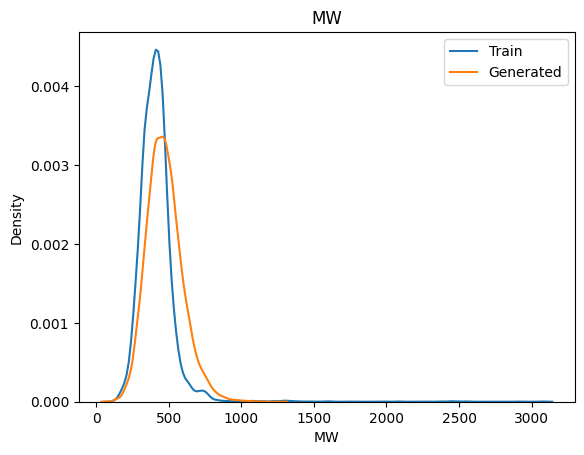

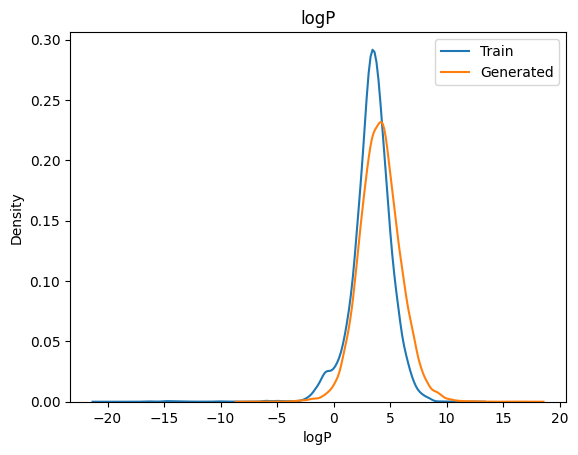

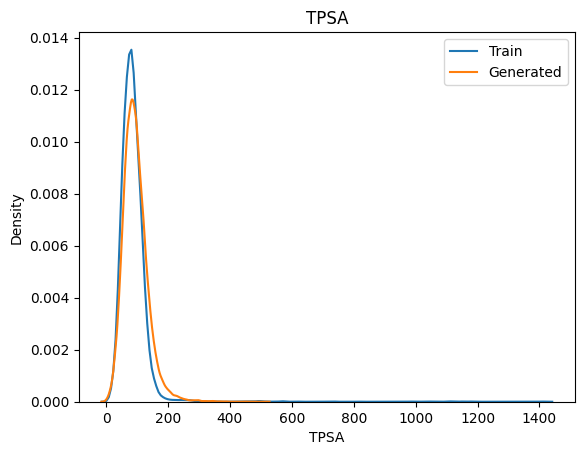

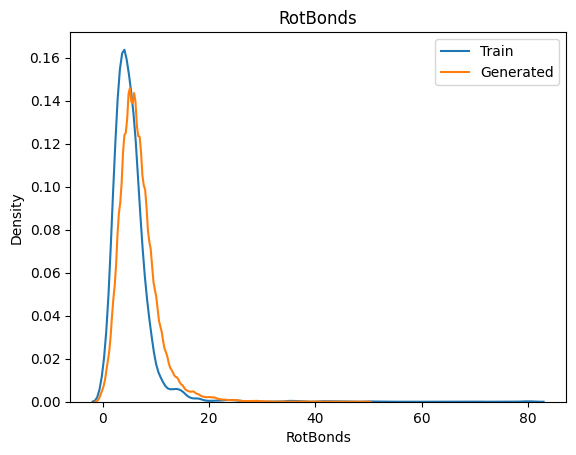

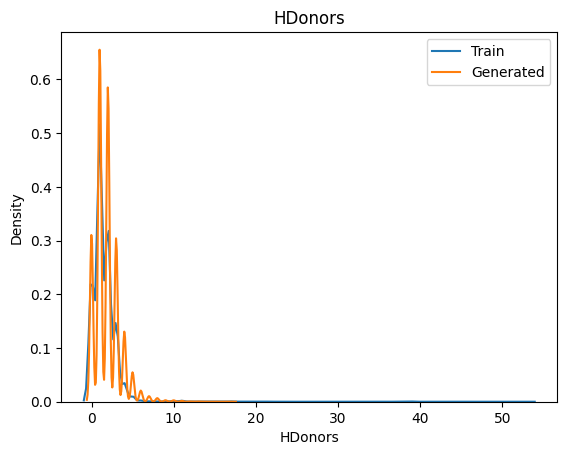

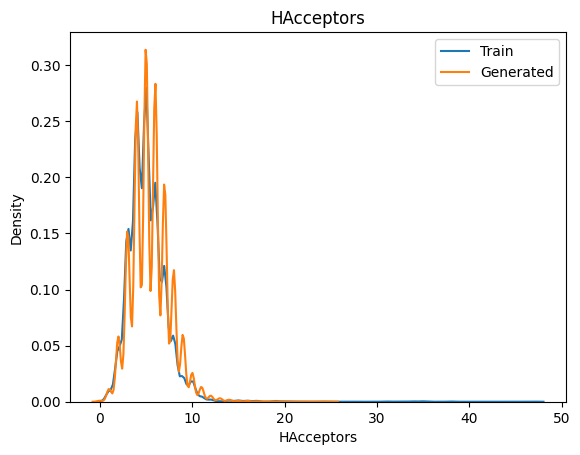

In [ ]:
# =========================
# 8. DISTRIBUTION ANALYSIS
# =========================
columns = ["MW", "logP", "TPSA", "RotBonds", "HDonors", "HAcceptors"]

gen_df = pd.DataFrame(gen_desc, columns=columns)
train_df = pd.DataFrame(train_desc, columns=columns)

for col in columns:
    plt.figure()
    sns.kdeplot(train_df[col], label="Train")
    sns.kdeplot(gen_df[col], label="Generated")
    plt.title(col)
    plt.legend()
    plt.show()

In [ ]:
from rdkit import Chem

def canonical_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    return None

# Приводим все SMILES к каноническому виду
train_canonical = {canonical_smiles(smi) for smi in train_valid_smiles if canonical_smiles(smi)}
gen_canonical = [canonical_smiles(smi) for smi in gen_valid_smiles if canonical_smiles(smi)]

# Проверяем пересечение
gen_in_train_canonical = [smi for smi in gen_canonical if smi in train_canonical]

print(f"После канонизации:")
print(f"  Дубликатов: {len(gen_in_train_canonical)}")
print(f"  Новых: {len(gen_canonical) - len(gen_in_train_canonical)}")

После канонизации:
  Дубликатов: 0
  Новых: 29232
